![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 02 | Processing and Database Design

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Turning one flat file into a relational database: clean the data, split it into tables, wire up the keys, load it into SQLite.

> **Done when:** `data/project.db` exists with 3+ related tables, `sql/schema.sql` matches your ERD, no foreign key is dangling, and the row counts are what you expect.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [34]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

In [35]:
listings_raw = pd.read_csv("../data/raw/listings.csv.gz")
reviews_raw = pd.read_csv("../data/raw/reviews.csv.gz")

print("Listings:", listings_raw.shape)
print("Reviews:", reviews_raw.shape)

Listings: (15293, 90)
Reviews: (1033523, 6)


In [36]:
location_check = (
    listings_raw
    .groupby("neighbourhood_cleansed")["neighbourhood_group_cleansed"]
    .nunique())

location_check[location_check > 1]

Series([], Name: neighbourhood_group_cleansed, dtype: int64)

### Location structure check

Each neighbourhood maps to exactly one Barcelona district. No neighbourhood appeared in more than one district.

This confirms that neighbourhood and district can be stored together in a single `locations` table without creating conflicting relationships.

In [37]:
locations = build_locations(listings_raw)

locations.head()

,location_id,neighbourhood_name,district_name
0,1,la Sagrada Família,Eixample
1,2,el Besòs i el Maresme,Sant Martí
2,3,el Barri Gòtic,Ciutat Vella
3,4,la Barceloneta,Ciutat Vella
4,5,la Dreta de l'Eixample,Eixample


In [38]:
print("Rows:", len(locations))
print("Unique location IDs:", locations["location_id"].nunique())
print("Unique neighbourhoods:", locations["neighbourhood_name"].nunique())
print("Duplicate neighbourhoods:", locations["neighbourhood_name"].duplicated().sum())

Rows: 69
Unique location IDs: 69
Unique neighbourhoods: 69
Duplicate neighbourhoods: 0


---
## 2. Clean, Transform and Build the Relational Tables

Work through the problems you listed in notebook 01. Every decision you make here — drop the nulls or keep them, cast or discard — is one you may be asked to defend on Friday, so note why.

### Select the fields needed for the analysis

The raw listings file contains 90 columns, but most are not needed for the database or the three research questions.

I am creating a smaller working dataset containing only the fields needed for pricing, location, host concentration, review activity and the supporting occupancy/revenue estimates. This keeps the cleaning process focused and avoids carrying unnecessary data into the final database.

In [39]:
listings_clean = listings_raw[
    [
        "id",
        "host_id",
        "host_name",
        "host_is_superhost",
        "neighbourhood_cleansed",
        "neighbourhood_group_cleansed",
        "room_type",
        "accommodates",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "estimated_occupancy_l365d",
        "estimated_revenue_l365d"]].copy()

listings_clean.shape

(15293, 13)

### Clarify the listing identifier

The source column `id` identifies each Airbnb listing. I am renaming it to `listing_id` so its purpose is clear once the data is split across several related tables.

In [40]:
listings_clean = listings_clean.rename(columns={"id": "listing_id"})

listings_clean.head()

,listing_id,host_id,host_name,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,room_type,accommodates,price,minimum_nights,number_of_reviews,estimated_occupancy_l365d,estimated_revenue_l365d
0,18674,71615,Maria Y Mireia Barcelona4Seasons,f,la Sagrada Família,Eixample,Entire home/apt,8,$409.00,1.0,59,54,22086.0
1,23197,90417,Marnie,t,el Besòs i el Maresme,Sant Martí,Entire home/apt,5,$388.00,2.0,99,66,25608.0
2,34981,73163,Andres,t,el Barri Gòtic,Ciutat Vella,Entire home/apt,9,$397.13,1.0,304,222,88163.0
3,36763,158596,Ester,f,la Barceloneta,Ciutat Vella,Private room,1,$43.24,31.0,108,0,0.0
4,40983,177617,Joaquin,t,la Dreta de l'Eixample,Eixample,Entire home/apt,4,$226.13,1.0,450,255,57663.0


### Clean the price field

`price` is stored as text because the values include a dollar sign, for example `$409.00`.

Notebook 01 confirmed that the non-null price values follow a consistent format, so I can remove the currency symbol and convert the remaining value to a numeric type.

Listings with a missing price will be kept in the dataset. They are still valid listings for the supply, host and review analyses, but they will be excluded from calculations that require a nightly price.

In [41]:
listings_clean["price"] = clean_price(
    listings_clean["price"]
)

print("Price type:", listings_clean["price"].dtype)
print("Missing prices:", listings_clean["price"].isna().sum())

listings_clean["price"].head()

Price type: float64
Missing prices: 1938


0    409.00
1    388.00
2    397.13
3     43.24
4    226.13
Name: price, dtype: float64

### Prepare the reviews data

The reviews file already has a simple structure, but the identifier and date columns need clearer names and the review date needs to be converted from text into a proper date type.

I am keeping only the fields needed to link reviews back to listings and measure review activity over time.

In [42]:
reviews_clean = clean_reviews(reviews_raw)

reviews_clean.head()

,review_id,listing_id,review_date
0,37494155,6088098,2015-07-07
1,162018938,18956901,2017-06-19
2,169085884,18956901,2017-07-11
3,172187716,18956901,2017-07-20
4,174791715,18956901,2017-07-27


In [43]:
print("Rows:", len(reviews_clean))
print("Unique review IDs:", reviews_clean["review_id"].nunique())
print("Missing review dates:", reviews_clean["review_date"].isna().sum())
print("Review date type:", reviews_clean["review_date"].dtype)

Rows: 1033523
Unique review IDs: 1033523
Missing review dates: 0
Review date type: datetime64[us]


### Check host consistency

Before creating one row per host, I need to check that repeated `host_id` values are associated with consistent host information.

If the same host ID appears with different names or superhost values, I need to understand that before reducing the data to one row per host.

In [44]:
host_name_check = (
    listings_clean
    .groupby("host_id")["host_name"]
    .nunique(dropna=False))

superhost_check = (
    listings_clean
    .groupby("host_id")["host_is_superhost"]
    .nunique(dropna=False))

print("Hosts with multiple names:", (host_name_check > 1).sum())
print("Hosts with multiple superhost values:", (superhost_check > 1).sum())

Hosts with multiple names: 0
Hosts with multiple superhost values: 0


### Build the hosts table

Each `host_id` is associated with one consistent host name and superhost value, so the repeated host information can safely be separated from the listings data.

The `hosts` table will therefore contain one row per host, identified by `host_id`.

In [45]:
hosts = (
    listings_clean[["host_id", "host_name", "host_is_superhost"]]
    .drop_duplicates(subset="host_id")
    .reset_index(drop=True))

hosts.head()

,host_id,host_name,host_is_superhost
0,71615,Maria Y Mireia Barcelona4Seasons,f
1,90417,Marnie,t
2,73163,Andres,t
3,158596,Ester,f
4,177617,Joaquin,t


In [46]:
print("Rows:", len(hosts))
print("Unique host IDs:", hosts["host_id"].nunique())
print("Duplicate host IDs:", hosts["host_id"].duplicated().sum())

Rows: 4595
Unique host IDs: 4595
Duplicate host IDs: 0


### Link listings to the locations table

The final listings table should reference the `locations` table using `location_id` rather than repeating the neighbourhood and district names on every listing.

I am merging the location ID back onto each listing using the neighbourhood and district combination already verified earlier.

In [47]:
listings_clean = listings_clean.merge(
    locations,
    left_on=["neighbourhood_cleansed", "neighbourhood_group_cleansed"],
    right_on=["neighbourhood_name", "district_name"],
    how="left",
    validate="many_to_one")

print("Rows after merge:", len(listings_clean))
print("Missing location IDs:", listings_clean["location_id"].isna().sum())

Rows after merge: 15293
Missing location IDs: 0


### Check the final listing fields

Before creating the final `listings` table, I am checking the fields that will be carried into the database for missing values.

This lets me make any remaining cleaning decisions deliberately rather than discovering problems after the tables have already been built.

In [48]:
final_listing_fields = [
    "listing_id",
    "host_id",
    "location_id",
    "room_type",
    "accommodates",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"]

listings_clean[final_listing_fields].isna().sum()

listing_id                      0
host_id                         0
location_id                     0
room_type                       0
accommodates                    0
price                        1938
minimum_nights                  1
number_of_reviews               0
estimated_occupancy_l365d       0
estimated_revenue_l365d      1938
dtype: int64

### Investigate remaining missing values

Most of the fields required for the final listings table are complete. The remaining missing values are in `price`, `estimated_revenue_l365d` and one `minimum_nights` record.

Before deciding how to handle them, I am checking whether the missing revenue values correspond directly to listings with missing prices and inspecting the single missing minimum-stay record.

In [49]:
same_missing_pattern = (
    listings_clean["price"].isna()
    == listings_clean["estimated_revenue_l365d"].isna()).all()

print("Price and estimated revenue have the same missing pattern:", same_missing_pattern)

listings_clean.loc[
    listings_clean["minimum_nights"].isna(),
    [
        "listing_id",
        "host_id",
        "room_type",
        "accommodates",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "estimated_occupancy_l365d",
        "estimated_revenue_l365d"]]

Price and estimated revenue have the same missing pattern: True


,listing_id,host_id,room_type,accommodates,price,minimum_nights,number_of_reviews,estimated_occupancy_l365d,estimated_revenue_l365d
3520,29047395,158023606,Entire home/apt,5,559.5,NaN,215,255,142673.0


### Missing minimum stay

One listing has a missing `minimum_nights` value, but the rest of the record is complete and useful for the analysis.

I am keeping the listing and leaving `minimum_nights` as missing rather than estimating or filling a value without evidence. This field is not required for the three core research questions, so removing the whole listing would unnecessarily discard valid information.

### Missing price and revenue values

The 1,938 missing `estimated_revenue_l365d` values occur on exactly the same listings as the 1,938 missing `price` values.

These listings will be kept because they still contain valid information for the supply, host and review analyses. Missing price and revenue values will remain as NULL rather than being estimated, and those records will be excluded only from calculations that require those fields.

In [50]:
listings = listings_clean[
    [
        "listing_id",
        "host_id",
        "location_id",
        "room_type",
        "accommodates",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "estimated_occupancy_l365d",
        "estimated_revenue_l365d"]].copy()

listings.head()

,listing_id,host_id,location_id,room_type,accommodates,price,minimum_nights,number_of_reviews,estimated_occupancy_l365d,estimated_revenue_l365d
0,18674,71615,1,Entire home/apt,8,409.00,1.0,59,54,22086.0
1,23197,90417,2,Entire home/apt,5,388.00,2.0,99,66,25608.0
2,34981,73163,3,Entire home/apt,9,397.13,1.0,304,222,88163.0
3,36763,158596,4,Private room,1,43.24,31.0,108,0,0.0
4,40983,177617,5,Entire home/apt,4,226.13,1.0,450,255,57663.0


### Validate the listings table

The final listings table now contains only the fields required for the database and analysis.

I am checking that `listing_id` is a valid primary key and that every `host_id` and `location_id` points to an existing record in the related tables.

In [51]:
print("Rows:", len(listings))
print("Unique listing IDs:", listings["listing_id"].nunique())
print("Duplicate listing IDs:", listings["listing_id"].duplicated().sum())

print(
    "Missing host references:",
    check_foreign_keys(
        listings,
        "host_id",
        hosts,
        "host_id"
    )
)

print(
    "Missing location references:",
    check_foreign_keys(
        listings,
        "location_id",
        locations,
        "location_id"
    )
)

Rows: 15293
Unique listing IDs: 15293
Duplicate listing IDs: 0
Missing host references: 0
Missing location references: 0


### Validate the reviews relationship

Each review should reference a valid listing through `listing_id`.

I am checking for any review records whose `listing_id` does not exist in the final listings table before the database is created.

In [52]:
print("Rows:", len(reviews_clean))
print("Unique review IDs:", reviews_clean["review_id"].nunique())
print("Duplicate review IDs:", reviews_clean["review_id"].duplicated().sum())

print(
    "Missing listing references:",
    (~reviews_clean["listing_id"].isin(listings["listing_id"])).sum()
)

Rows: 1033523
Unique review IDs: 1033523
Duplicate review IDs: 0
Missing listing references: 6592


In [53]:
orphan_reviews = reviews_clean[
    ~reviews_clean["listing_id"].isin(listings["listing_id"])]

print("Orphan review rows:", len(orphan_reviews))
print("Unique missing listing IDs:", orphan_reviews["listing_id"].nunique())
print("Earliest orphan review:", orphan_reviews["review_date"].min())
print("Latest orphan review:", orphan_reviews["review_date"].max())

Orphan review rows: 6592
Unique missing listing IDs: 77
Earliest orphan review: 2018-09-25 00:00:00
Latest orphan review: 2026-07-01 00:00:00


### Remove reviews without a matching listing

The review data contains 6,592 reviews linked to 77 listing IDs that do not appear in the current listings dataset.

The source data does not explain why those listings are absent, so no assumption is made about their status. However, these reviews cannot be included in the relational database because they would create invalid foreign-key references.

I therefore exclude these unmatched reviews from the final `reviews` table. The original raw data remains unchanged.

In [54]:
reviews = reviews_clean[
    reviews_clean["listing_id"].isin(listings["listing_id"])].copy()

print("Final review rows:", len(reviews))
print(
    "Missing listing references:",
    (~reviews["listing_id"].isin(listings["listing_id"])).sum())

Final review rows: 1026931
Missing listing references: 0


### Estimated occupancy and revenue

I have kept the estimated occupancy and revenue fields because they are useful for the investor view, but they are modelled indicators rather than observed bookings or actual revenue. I will therefore use them as supporting evidence, not as confirmed performance.

---
## 3. Design your tables

Decide what your tables are and how they relate before you write any code. Draw the ERD (Excalidraw, draw.io), export it as an image, commit it, and link it from your README.

Three tables minimum, with real primary and foreign keys.

### Final table and relationship validation

Before exporting the cleaned data, I am performing a final check of the four database tables.

This confirms that each primary key is unique and that all foreign-key values have a matching parent record.

In [55]:
print("LOCATIONS")
print("Rows:", len(locations))
print("Unique PKs:", locations["location_id"].nunique())

print("\nHOSTS")
print("Rows:", len(hosts))
print("Unique PKs:", hosts["host_id"].nunique())

print("\nLISTINGS")
print("Rows:", len(listings))
print("Unique PKs:", listings["listing_id"].nunique())
print("Invalid host IDs:", (~listings["host_id"].isin(hosts["host_id"])).sum())
print("Invalid location IDs:", (~listings["location_id"].isin(locations["location_id"])).sum())

print("\nREVIEWS")
print("Rows:", len(reviews))
print("Unique PKs:", reviews["review_id"].nunique())
print("Invalid listing IDs:", (~reviews["listing_id"].isin(listings["listing_id"])).sum())

LOCATIONS
Rows: 69
Unique PKs: 69

HOSTS
Rows: 4595
Unique PKs: 4595

LISTINGS
Rows: 15293
Unique PKs: 15293
Invalid host IDs: 0
Invalid location IDs: 0

REVIEWS
Rows: 1026931
Unique PKs: 1026931
Invalid listing IDs: 0


### Export the cleaned tables

I have now cleaned and checked the four tables, so I am exporting them as separate CSV files.

This gives me a clean version of the data to work from without changing the original raw files, and means the database can be rebuilt from the cleaned tables if I need to.

---
## 3. Final Database Design and ERD

Split the cleaned data into the tables you designed.

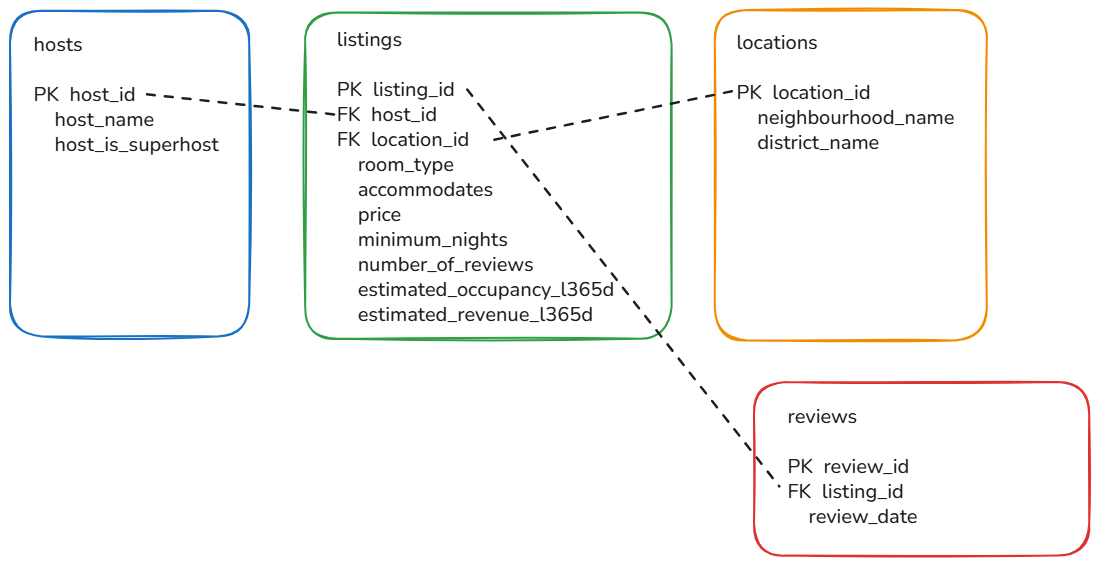

### Database design

I split the data into four related tables: `hosts`, `locations`, `listings` and `reviews`.

`listings` is the main table and connects each property to one host and one location. `reviews` then connects back to `listings` using `listing_id`.

This keeps repeated host and location information out of the listings table and gives me a structure that is easier to query in SQL.

---
## 4. Export the Clean Tables

I have finished cleaning and checking the four tables, so I am exporting them as separate CSV files before building the SQLite database.

This gives me a clean version of each table to work from without changing the original raw data.

In [56]:
from pathlib import Path

clean_dir = Path("../data/clean")
clean_dir.mkdir(parents=True, exist_ok=True)

locations.to_csv(clean_dir / "locations.csv", index=False)
hosts.to_csv(clean_dir / "hosts.csv", index=False)
listings.to_csv(clean_dir / "listings.csv", index=False)
reviews.to_csv(
    clean_dir / "reviews.csv",
    index=False,
    date_format="%Y-%m-%d")

print("Clean tables exported successfully.")

Clean tables exported successfully.


In [57]:
for file in clean_dir.iterdir():
    print(file.name)

.gitkeep
hosts.csv
listings.csv
locations.csv
reviews.csv


---
## 5. Create the Database and Load It



In [58]:
import sqlite3

db_path = "../data/project.db"
schema_path = "../sql/schema.sql"

conn = sqlite3.connect(db_path)
conn.execute("PRAGMA foreign_keys = ON;")

with open(schema_path, "r") as file:
    schema = file.read()

conn.executescript(schema)

print("Foreign keys enabled:", conn.execute("PRAGMA foreign_keys;").fetchone()[0])

tables = conn.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""").fetchall()

print("Tables:", tables)

Foreign keys enabled: 1
Tables: [('hosts',), ('listings',), ('locations',), ('reviews',)]


### Load the parent tables

I am loading `hosts` and `locations` first because they do not contain foreign keys. The listings table will reference both of these, so their records need to exist before the listings are added.

In [59]:
locations.to_sql(
    "locations",
    conn,
    if_exists="append",
    index=False
)

hosts.to_sql(
    "hosts",
    conn,
    if_exists="append",
    index=False
)

print(
    "Locations:",
    conn.execute("SELECT COUNT(*) FROM locations;").fetchone()[0]
)

print(
    "Hosts:",
    conn.execute("SELECT COUNT(*) FROM hosts;").fetchone()[0]
)

Locations: 69
Hosts: 4595


### Load the listings table

Now that the host and location records are in the database, I can load the listings table without breaking its foreign-key relationships.

In [60]:
listings.to_sql(
    "listings",
    conn,
    if_exists="append",
    index=False
)

print(
    "Listings:",
    conn.execute("SELECT COUNT(*) FROM listings;").fetchone()[0]
)

Listings: 15293


### Load the reviews table

Reviews are loaded last because each review must link to an existing listing. I am storing the review date as `YYYY-MM-DD`, which keeps the format simple and consistent for SQLite queries.

In [61]:
reviews_for_db = reviews.copy()

reviews_for_db["review_date"] = (
    reviews_for_db["review_date"]
    .dt.strftime("%Y-%m-%d")
)

reviews_for_db.to_sql(
    "reviews",
    conn,
    if_exists="append",
    index=False
)

print(
    "Reviews:",
    conn.execute("SELECT COUNT(*) FROM reviews;").fetchone()[0]
)

Reviews: 1026931


---
## 6. Verify the Database

Row counts per table, and one join that returns the rows you expect. Then open `data/project.db` in DB Browser and look at it.

## 6. Verify the Database

The database is now loaded, so I am checking that the row counts match the cleaned tables and that SQLite reports no foreign-key problems.

In [62]:
for table in ["locations", "hosts", "listings", "reviews"]:
    count = conn.execute(
        f"SELECT COUNT(*) FROM {table};"
    ).fetchone()[0]

    print(f"{table}: {count}")

fk_issues = conn.execute(
    "PRAGMA foreign_key_check;"
).fetchall()

print("Foreign key issues:", len(fk_issues))

locations: 69
hosts: 4595
listings: 15293
reviews: 1026931
Foreign key issues: 0


### Test the relationships

As a final check, I am joining listings to their host and location records to make sure the relationships work as expected in the database.

In [63]:
test_join = pd.read_sql("""
    SELECT
        l.listing_id,
        h.host_name,
        loc.neighbourhood_name,
        loc.district_name,
        l.room_type,
        l.price
    FROM listings AS l
    JOIN hosts AS h
        ON l.host_id = h.host_id
    JOIN locations AS loc
        ON l.location_id = loc.location_id
    LIMIT 5;
""", conn)

test_join

,listing_id,host_name,neighbourhood_name,district_name,room_type,price
0,18674,Maria Y Mireia Barcelona4Seasons,la Sagrada Família,Eixample,Entire home/apt,409.00
1,23197,Marnie,el Besòs i el Maresme,Sant Martí,Entire home/apt,388.00
2,34981,Andres,el Barri Gòtic,Ciutat Vella,Entire home/apt,397.13
3,36763,Ester,la Barceloneta,Ciutat Vella,Private room,43.24
4,40983,Joaquin,la Dreta de l'Eixample,Eixample,Entire home/apt,226.13


In [64]:
conn.close()
print("Database connection closed.")

Database connection closed.
